# **Assignment 3**


# Part A — Heat Equation

We need to solve
u
(t)=0.4u xx​


for x∈[0,1],t∈[0,1]

with

u(0,t)=0,u(1,t)=0

and

u(x,0)=sin(πx)

Analytical solution:

u(x,t)=e
−0.4π
2
t
sin(πx)

In [7]:
!pip install deepxde

In [8]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Exact solution
# --------------------------------------------------

def exact_solution(x, t):
    return np.exp(-0.4*np.pi**2*t) * np.sin(np.pi*x)

# --------------------------------------------------
# PDE
# --------------------------------------------------

def heat_pde(X, u):

    du_t = dde.grad.jacobian(u, X, i=0, j=1)

    du_xx = dde.grad.hessian(u, X, i=0, j=0)

    return du_t - 0.4*du_xx

# --------------------------------------------------
# Geometry
# --------------------------------------------------

geom = dde.geometry.Interval(0, 1)

timedomain = dde.geometry.TimeDomain(0, 1)

geomtime = dde.geometry.GeometryXTime(
    geom,
    timedomain
)

# --------------------------------------------------
# BC
# --------------------------------------------------

bc = dde.icbc.DirichletBC(
    geomtime,
    lambda X: 0,
    lambda X, on_boundary: on_boundary
)

# --------------------------------------------------
# IC
# --------------------------------------------------

ic = dde.icbc.IC(
    geomtime,
    lambda X: np.sin(np.pi*X[:,0:1]),
    lambda _, on_initial: on_initial
)

# --------------------------------------------------
# Data
# --------------------------------------------------

data = dde.data.TimePDE(
    geomtime,
    heat_pde,
    [bc, ic],
    num_domain=2000,
    num_boundary=200,
    num_initial=200
)

# --------------------------------------------------
# Network
# --------------------------------------------------

net = dde.nn.FNN(
    [2] + [64]*4 + [1],
    "tanh",
    "Glorot normal"
)

model = dde.Model(data, net)

model.compile(
    "adam",
    lr=1e-3
)

model.train(iterations=10000)

Compiling model...
'compile' took 0.005817 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x797438c434c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x797438c434c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x797438c43600>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x797438c43600>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
0         [1.81e-04, 1.51e-04, 5.07e-01]    [1.81e-04, 1.51e-04, 5.07e-01]    []  
1000      [5.60e-03, 2.03e-03, 5.79e-04]    [5.60e-03, 2.03e-03, 5.79e-04]    []  
2000      [7.48e-05, 3.66e-05, 2.74e-05]    [7.48e-05, 3.66e-05, 2.74e-05]    []  
3000      [5.69e-05, 2.21e-05, 8.28e-06]    [5.69e-05, 2.21e-05, 8.28e-06]    []  
4000      [3.09e-05, 4.04e-05, 3.61e-05]    [3.09e-05, 4.04e-05, 3.61e-05]    []  
5000      [1.73e-05, 7.22e-06, 1.90e-06]    [1.73e-05, 7.22e-06, 1.90e-06]    []  
6000      [3.42e-0

(<deepxde.model.LossHistory at 0x797438c51100>,
 <deepxde.model.TrainState at 0x797438b12570>)

In [9]:
nx = 100
nt = 100

x = np.linspace(0,1,nx)
t = np.linspace(0,1,nt)

X,T = np.meshgrid(x,t)

XT = np.hstack([
    X.reshape(-1,1),
    T.reshape(-1,1)
])

u_pinn = model.predict(XT)

u_exact = exact_solution(
    XT[:,0:1],
    XT[:,1:2]
)

u_pinn = u_pinn.reshape(nt,nx)
u_exact = u_exact.reshape(nt,nx)

Heatmap of PINN Solution

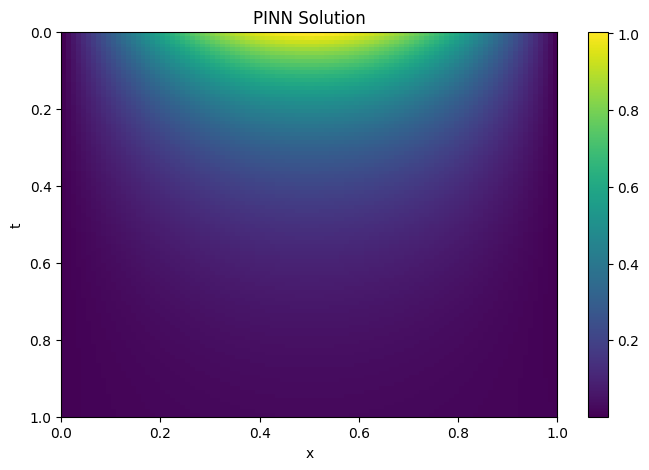

In [10]:
plt.figure(figsize=(8,5))

plt.imshow(
    u_pinn,
    extent=[0,1,1,0],
    aspect="auto"
)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Solution")
plt.show()

Exact Soln Heatmap

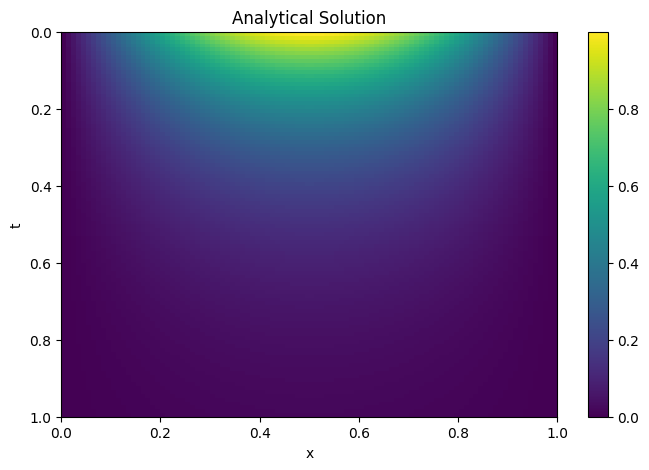

In [11]:
plt.figure(figsize=(8,5))

plt.imshow(
    u_exact,
    extent=[0,1,1,0],
    aspect="auto"
)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("Analytical Solution")
plt.show()

Absolute error

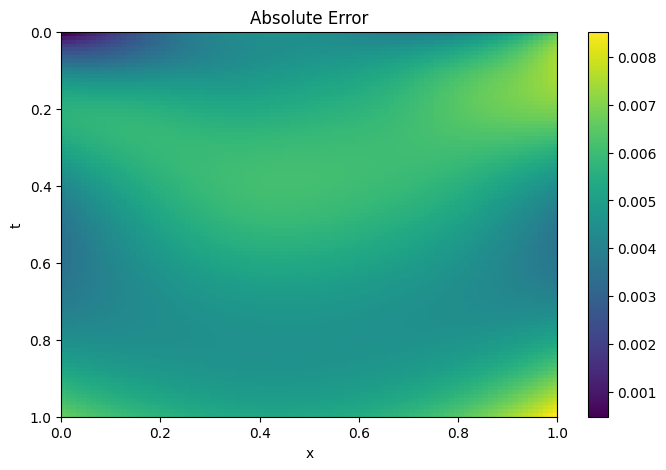

In [12]:
error = np.abs(u_pinn-u_exact)

plt.figure(figsize=(8,5))

plt.imshow(
    error,
    extent=[0,1,1,0],
    aspect="auto"
)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("Absolute Error")
plt.show()

Relative L^2 error

In [13]:
l2_error = (
    np.linalg.norm(u_pinn-u_exact)
    /
    np.linalg.norm(u_exact)
)

print("Relative L2 Error:", l2_error)

Relative L2 Error: 0.020523784074751385


# Part B — Collocation Sampling Experiment

In [ ]:
collocation_points = [
    500,
    1000,
    2500,
    5000,
    10000
]

errors = []

for N in collocation_points:

    data = dde.data.TimePDE(
        geomtime,
        heat_pde,
        [bc, ic],
        num_domain=N,
        num_boundary=100,
        num_initial=100
    )

    net = dde.nn.FNN(
        [2] + [64]*3 + [1],
        "tanh",
        "Glorot normal"
    )

    model = dde.Model(data, net)

    model.compile(
        "adam",
        lr=1e-3
    )

    model.train(iterations=2000)

    pred = model.predict(XT)

    err = (
        np.linalg.norm(
            pred - u_exact.reshape(-1,1)
        )
        /
        np.linalg.norm(
            u_exact.reshape(-1,1)
        )
    )

    errors.append(err)

    print(
        f"N = {N}, Error = {err:.6f}"
    )

Compiling model...
'compile' took 0.004160 s

Training model...

0         [2.57e-02, 2.05e-02, 5.49e-01]    [2.57e-02, 2.05e-02, 5.49e-01]    []  
1000      [5.56e-04, 1.89e-04, 1.12e-04]    [5.56e-04, 1.89e-04, 1.12e-04]    []  
2000      [1.24e-04, 6.10e-05, 2.74e-05]    [1.24e-04, 6.10e-05, 2.74e-05]    []  

Best model at step 2000:
  train loss: 2.12e-04
  test loss: 2.12e-04
  test metric: []

'train' took 23.025488 s

N = 500, Error = 0.018309
Compiling model...
'compile' took 0.003179 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [2.51e-02, 2.04e-02, 5.49e-01]    [2.51e-02, 2.04e-02, 5.49e-01]    []  
1000      [6.14e-04, 2.15e-04, 1.21e-04]    [6.14e-04, 2.15e-04, 1.21e-04]    []  
2000      [1.41e-04, 6.21e-05, 3.29e-05]    [1.41e-04, 6.21e-05, 3.29e-05]    []  

Best model at step 2000:
  train loss: 2.36e-04
  test loss: 2.36e-04
  test metric: []

'train' took 33.453863 s

N = 1000, Error = 0.0167

Step      Train loss                        Test loss                         Test metric
0         [2.46e-02, 2.05e-02, 5.49e-01]    [2.46e-02, 2.05e-02, 5.49e-01]    []  
1000      [5.50e-04, 1.63e-04, 1.02e-04]    [5.50e-04, 1.63e-04, 1.02e-04]    []  
2000      [1.35e-04, 4.94e-05, 2.64e-05]    [1.35e-04, 4.94e-05, 2.64e-05]    []  

Best model at step 2000:
  train loss: 2.11e-04
  test loss: 2.11e-04
  test metric: []

'train' took 62.432705 s

N = 2500, Error = 0.016794
Compiling model...
'compile' took 0.003424 s

Training model...



Step      Train loss                        Test loss                         Test metric
0         [2.44e-02, 2.12e-02, 5.49e-01]    [2.44e-02, 2.12e-02, 5.49e-01]    []  
1000      [5.10e-04, 1.18e-04, 8.40e-05]    [5.10e-04, 1.18e-04, 8.40e-05]    []  
2000      [1.06e-04, 4.08e-05, 2.29e-05]    [1.06e-04, 4.08e-05, 2.29e-05]    []  

Best model at step 2000:
  train loss: 1.70e-04
  test loss: 1.70e-04
  test metric: []

'train' took 107.793529 s

N = 5000, Error = 0.015651
Compiling model...
'compile' took 0.003301 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [2.43e-02, 1.83e-02, 5.49e-01]    [2.43e-02, 1.83e-02, 5.49e-01]    []  


A single plot of L² relative error vs number of collocation points.

In [ ]:
plt.plot(
    collocation_points,
    errors,
    marker="o"
)

plt.xlabel("Collocation Points")
plt.ylabel("Relative L2 Error")
plt.title("Error vs Collocation Points")
plt.grid()
plt.show()

Observation

You should observe:

Error decreases as collocation points increase.
Improvement is rapid initially.
Beyond a few thousand points, gains become smaller.



# Part C: Wave Equation

We solve the 1D wave equation

$$
u_{tt} = u_{xx}
$$

on

$$
x \in [0,1], \quad t \in [0,1]
$$

with

$$
u(0,t)=0,\qquad u(1,t)=0
$$

and initial conditions

$$
u(x,0)=\sin(\pi x)
$$

$$
u_t(x,0)=0
$$



In [ ]:
def wave_pde(X, u):

    u_tt = dde.grad.hessian(
        u,
        X,
        i=1,
        j=1
    )

    u_xx = dde.grad.hessian(
        u,
        X,
        i=0,
        j=0
    )

    return u_tt - u_xx

Initial Displacement Condition

In [ ]:
ic1 = dde.icbc.IC(
    geomtime,
    lambda X: np.sin(np.pi * X[:, 0:1]),
    lambda _, on_initial: on_initial
)

Initial Velocity Condition

In [ ]:
ic2 = dde.icbc.OperatorBC(
    geomtime,
    lambda X, u, _: dde.grad.jacobian(
        u,
        X,
        i=0,
        j=1
    ),
    lambda _, on_initial: on_initial
)

Boundary Condition

In [ ]:
bc = dde.icbc.DirichletBC(
    geomtime,
    lambda X: 0,
    lambda X, on_boundary: on_boundary
)

Data

In [ ]:
data = dde.data.TimePDE(
    geomtime,
    wave_pde,
    [bc, ic1, ic2],
    num_domain=5000,
    num_boundary=200,
    num_initial=200
)

net = dde.nn.FNN(
    [2] + [64]*4 + [1],
    "tanh",
    "Glorot normal"
)

model = dde.Model(data, net)

model.compile(
    "adam",
    lr=1e-3
)

In [ ]:
losshistory, train_state = model.train(
    iterations=10000
)

Soln

In [ ]:
nx = 100
nt = 100

x = np.linspace(0, 1, nx)
t = np.linspace(0, 1, nt)

X, T = np.meshgrid(x, t)

XT = np.hstack([
    X.reshape(-1, 1),
    T.reshape(-1, 1)
])

u_wave = model.predict(XT)

u_wave = u_wave.reshape(nt, nx)

In [ ]:
Plot

In [ ]:
plt.figure(figsize=(8,5))

plt.imshow(
    u_wave,
    extent=[0,1,1,0],
    aspect="auto"
)

plt.colorbar(label="u(x,t)")

plt.xlabel("x")
plt.ylabel("t")

plt.title("Wave Equation PINN Solution")

plt.show()

The solution of the wave equation was visualized using a heatmap over the space-time domain. Unlike the heat equation, which exhibits diffusion and amplitude decay, the wave equation maintains oscillatory behavior throughout the domain. The PINN successfully captures these propagating oscillations while satisfying the imposed boundary and initial conditions.